# 21. Built-in Flatte presets

**Objectives:**
- Build several of the literature `Flatte` presets (`f0_980`, `k0star_1430_neutral`/`_charged`,
  `a0_980_neutral`/`_charged`) from their classmethod constructors.
- Compare their default couplings and channel thresholds side by side on one plot.
- Put one preset in a minimal `DecayModel`, generate a toy, and run a quick fit with the
  shape held fixed.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and daughter
indices start at zero. This continues [tutorial 20](tutorial_20_flatte_generic.ipynb).

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, Flatte, NonResonant,
    Parameter, RealImag, Resonance, generate_toy,
)
from dalitzplotfitter.dynamics.context import ResonanceContext

## 1. Five literature presets

`Flatte` ships classmethod presets that hard-code the Laura++ default literature couplings
and channel masses for well-known scalars:

- `Flatte.f0_980()`: pi-pi / K-Kbar channels, BES couplings `g1 = 0.165/0.965`, `g2 = 4.21*g1`.
- `Flatte.k0star_1430_neutral()` / `.k0star_1430_charged()`: K-pi / K-eta' channels with an
  Adler zero (`adler_zero=0.234`).
- `Flatte.a0_980_neutral()` / `.a0_980_charged()`: eta-pi / K-Kbar channels.

Each preset differs only in couplings and channel daughter masses -- the propagator formula
is the same `Flatte.__call__` for all of them. We pick their nominal pole masses from the
PDG values normally quoted alongside these parameterizations.

In [2]:
presets = {
    "f0(980)": (Flatte.f0_980(), 0.965),
    "K0*(1430) neutral": (Flatte.k0star_1430_neutral(), 1.425),
    "a0(980) neutral": (Flatte.a0_980_neutral(), 0.999),
}
for label, (flatte, pole_mass) in presets.items():
    print(f"{label}: g1={flatte.g1:.4f}, g2={flatte.g2:.4f}, adler_zero={flatte.adler_zero}")

f0(980): g1=0.1710, g2=0.7198, adler_zero=None
K0*(1430) neutral: g1=0.3040, g2=0.3800, adler_zero=0.234
a0(980) neutral: g1=0.1051, g2=0.1083, adler_zero=None


## 2. Compare magnitude and phase side by side

Each preset is evaluated over its own natural mass window via a minimal `ResonanceContext`.
The K0*(1430) curve shows a second-channel cusp (K-eta') well above its pole, while
f0(980) and a0(980) both show cusps near their own K-Kbar channel threshold.

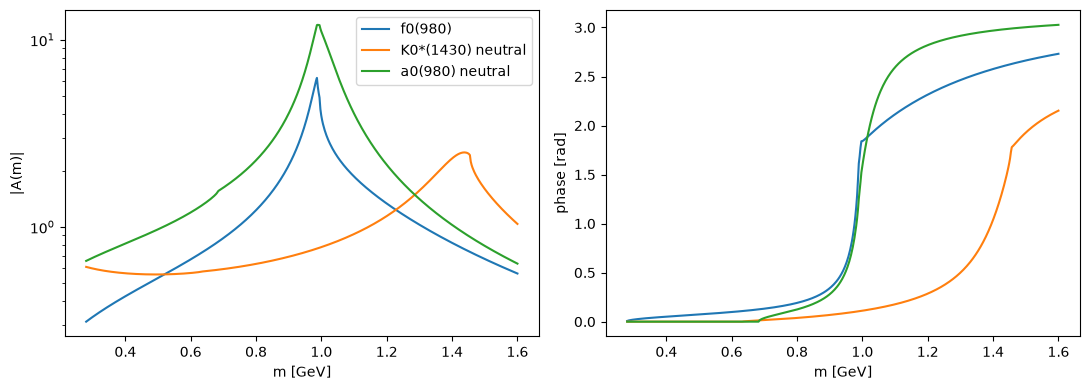

In [3]:
mpip = 0.13957039
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, (flatte, pole_mass) in presets.items():
    mass_scan = jnp.linspace(0.28, 1.60, 500)
    context = ResonanceContext(
        parent_mass=1.87, daughter_masses=(mpip, mpip), bachelor_mass=mpip,
        spin=0, pole_mass=pole_mass, pole_width=0.05,
    )
    amplitude_scan = flatte(mass_scan, context)
    axes[0].plot(mass_scan, jnp.abs(amplitude_scan), label=label)
    axes[1].plot(mass_scan, jnp.angle(amplitude_scan), label=label)
axes[0].set(xlabel="m [GeV]", ylabel="|A(m)|", yscale="log")
axes[1].set(xlabel="m [GeV]", ylabel="phase [rad]")
axes[0].legend()
fig.tight_layout()
plt.show()

## 3. One preset in a minimal Dalitz model

We take `Flatte.f0_980()` as the resonant component of a small `D+ -> pi- pi+ pi+` model,
generate a toy at its nominal pole mass, and fit that pole mass back with the couplings held
fixed -- couplings could equally well be floated using the same `Parameter.dynamics` pattern
shown in tutorial 20.

In [4]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
mass_param = Parameter.dynamics("f0_980.mass", 0.965, owner="f0_980", bounds=(0.90, 1.02), step=0.001)

model = DecayModel(
    channel,
    components=[
        Resonance(
            name="f0_980", pair=(0, 1), coefficient=RealImag(1.0, 0.0),
            lineshape=Flatte.f0_980(), mass=mass_param, width=0.05, spin=0,
            normalize_component=False,
        ),
        NonResonant(RealImag(0.20, -0.05), name="NR"),
    ],
    normalization_method="square-dalitz",
    normalization_pair=(0, 1),
    normalization_resolution=40,
)
truth = {p.name: p.value for p in model.parameters}

toy = generate_toy(
    model, 3000, parameters=truth, seed=21,
    method="inverse-transform", inverse_resolution=256,
    include_momenta=False,
)
print(f"Generated {toy.size} toy events")

session = FitSession(model, toy)
result = session.fit({"f0_980.mass": 0.945}, simplex=True, ncall=3000)
fit_value = float(result.values["f0_980.mass"])
fit_error = float(result.errors["f0_980.mass"])
print(f"truth mass = {truth['f0_980.mass']:.4f}, fit mass = {fit_value:.4f} +/- {fit_error:.4f}")

fit_values = {"f0_980.mass": fit_value}
assert result.valid, "Inspect the fit diagnostics before using this result."
assert float(session.objective(fit_values)) <= float(session.objective(truth)) + 1e-3
print("The fit converged to a valid minimum with NLL at or below the truth NLL.")

Generated 3000 toy events


truth mass = 0.9650, fit mass = 0.9908 +/- 0.0024


The fit converged to a valid minimum with NLL at or below the truth NLL.


## Summary

- The five `Flatte` classmethod presets differ only in couplings/channel masses/optional
  Adler zero; the propagator itself is the same class demonstrated from scratch in
  [tutorial 20](tutorial_20_flatte_generic.ipynb).
- Each still plugs into `Resonance(..., lineshape=...)` exactly like any other lineshape, and
  any of its fields (or the `Resonance` mass/width) can be replaced with
  `Parameter.dynamics(...)` to float it.

Continue with [tutorial 22](tutorial_22_babar_flatte.ipynb) for the BaBar Flatte
convention, which differs from `Flatte.f0_980()` in parameterization details.

Return to [the course guide](TUTORIALS.md).